# Machine Learning I - Fase 2 - Template


Nome: **Elisa Amaral**

## Aplicação e validação de algoritmos de Machine Learning


Nesta fase, o objetivo é usar os dados preparados na fase anterior para construir um classificador binário. Se for necessário selecionar ainda mais os atributos para que o classificador funcione melhor, comente as suas escolhas e a necessidade desse novo filtro.


Experimente ao menos 4 dos algoritmos vistos em aula para classificação. Obrigatoriamente, dentre esses 4 você deve incluir **Árvores de Decisão** e **MultiLayer Perceptron**. Explore os hiperparâmetros dos algoritmos visando a obtenção de melhores resultados.


#1) Escolha dos algoritmos e exploração dos hiper-parâmetros


Agora, você precisa escolher 2 algoritmos de classificação, junto com Árvore de decisão e MLP, e o conjunto de hiper parâmetros que será explorado.


In [ ]:
# Insira seu código aqui.
# Você pode criar células de código adicionais

# TODO
# 1) Criação dos modelos Árvore de decisão, MLP e mais dois algoritmos de sua escolha
# 2) Definição do cojunto de hiper-parâmetros a serem explorados (use GridSearch)
#     Link de referência: https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.GridSearchCV.html
# 3) Execução da exploração dos hiper-parâmetros e escolhe dos melhores estimadores

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_validate, train_test_split
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

df = pd.read_csv('TitanicNovoDataset.csv')
print('Shape:', df.shape)
print(df['Survived'].value_counts())
df.head()

Shape: (912, 10)
Survived
1    456
0    456
Name: count, dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0.5,1.0,0.4250,0.000,0.000000,0.049547,0,0,1
1,1,1.0,1.0,0.3375,0.000,0.166667,0.047546,0,0,1
2,1,0.5,1.0,0.1000,0.000,0.333333,0.100048,0,0,1
3,0,0.0,0.0,0.3750,0.000,0.000000,0.101191,0,0,1
4,0,0.0,0.0,0.6125,0.125,0.166667,0.422614,1,0,0


## Escolha dos algoritmos e exploração dos hiperparâmetros

**Atributos utilizados**

Todos os atributos preparados na Fase 1 foram mantidos para a classificação:
- **Pclass**: classe da passagem com forte correlação com sobrevivência (1ª classe sobreviveu ~58%).
- **Sex**: sexo do passageiro, uma variável com maior poder preditivo (mulheres sobreviveram ~69%).
- **Age**: idade, as crianças tinham prioridade de embarque nos salva-vidas.
- **SibSp / Parch**: composição familiar, o tamanho da família pode influenciar decisões de fuga.
- **Fare**: tarifa paga, correlacionada com classe social e localização no navio.
- **Embarked_C / Embarked_Q / Embarked_S**: porto de embarque, relacionado indiretamente à classe social e distribuição no navio.

O dataset já está balanceado (456 sobreviventes e 456 não sobreviventes), resultado do oversampling aplicado na Fase 1.

**Algoritmos escolhidos**

Obrigatórios:
- **Árvore de Decisão (Decision Tree)**: algoritmo interpretável que aprende regras de divisão recursiva baseadas nos atributos. Hiperparâmetros explorados: profundidade máxima (`max_depth`), mínimo de amostras para divisão (`min_samples_split`) e critério de impureza (`criterion`).
- **MLP (MultiLayer Perceptron)**: rede neural artificial com camadas ocultas. Hiperparâmetros explorados: arquitetura das camadas ocultas (`hidden_layer_sizes`) e regularização L2 (`alpha`).
Escolha adicional:
- **KNN (K-Nearest Neighbors)**: classifica com base nos K vizinhos mais próximos. Simples, não paramétrico, intuitivo. Hiperparâmetros explorados: número de vizinhos (`n_neighbors`) e esquema de ponderação (`weights`).
- **Naive Bayes (Gaussian)**: classificador probabilístico baseado no Teorema de Bayes com independência condicional entre atributos. Rápido e eficiente. Hiperparâmetro explorado: suavização (`var_smoothing`).

**Separação treino/teste e configuração da validação cruzada**

In [2]:
X = df.drop(columns=['Survived'])
y = df['Survived']

# Divisão estratificada: 80% treino, 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Treino:', X_train.shape, '| Teste:', X_test.shape)
print('Proporção alvo treino:', y_train.value_counts().to_dict())
print('Proporção alvo teste:', y_test.value_counts().to_dict())

# Validação cruzada estratificada com 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Treino: (729, 9) | Teste: (183, 9)
Proporção alvo treino: {1: 365, 0: 364}
Proporção alvo teste: {0: 92, 1: 91}


## GridSearchCV — Árvore de Decisão

In [3]:
dt_params = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params, cv=cv, scoring='accuracy', n_jobs=-1
)
dt_gs.fit(X_train, y_train)

print('Melhores hiperparâmetros (Árvore de Decisão):')
print(dt_gs.best_params_)
print(f'Melhor acurácia (CV treino): {dt_gs.best_score_:.4f}')

Melhores hiperparâmetros (Árvore de Decisão):
{'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}
Melhor acurácia (CV treino): 0.8217


## GridSearchCV — MLP

In [4]:
mlp_params = {
    'hidden_layer_sizes': [(64,), (64, 32), (128, 64)],
    'alpha': [0.0001, 0.001]
}

mlp_gs = GridSearchCV(
    MLPClassifier(max_iter=1000, random_state=42),
    mlp_params, cv=cv, scoring='accuracy', n_jobs=-1
)
mlp_gs.fit(X_train, y_train)

print('Melhores hiperparâmetros (MLP):')
print(mlp_gs.best_params_)
print(f'Melhor acurácia (CV treino): {mlp_gs.best_score_:.4f}')

Melhores hiperparâmetros (MLP):
{'alpha': 0.001, 'hidden_layer_sizes': (128, 64)}
Melhor acurácia (CV treino): 0.8231


## GridSearchCV — KNN

In [5]:
knn_params = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights': ['uniform', 'distance']
}

knn_gs = GridSearchCV(
    KNeighborsClassifier(),
    knn_params, cv=cv, scoring='accuracy', n_jobs=-1
)
knn_gs.fit(X_train, y_train)

print('Melhores hiperparâmetros (KNN):')
print(knn_gs.best_params_)
print(f'Melhor acurácia (CV treino): {knn_gs.best_score_:.4f}')

Melhores hiperparâmetros (KNN):
{'n_neighbors': 15, 'weights': 'distance'}
Melhor acurácia (CV treino): 0.8492


## GridSearchCV — Naive Bayes

In [6]:
nb_params = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

nb_gs = GridSearchCV(
    GaussianNB(),
    nb_params, cv=cv, scoring='accuracy', n_jobs=-1
)
nb_gs.fit(X_train, y_train)

print('Melhores hiperparâmetros (Naive Bayes):')
print(nb_gs.best_params_)
print(f'Melhor acurácia (CV treino): {nb_gs.best_score_:.4f}')

Melhores hiperparâmetros (Naive Bayes):
{'var_smoothing': 1e-09}
Melhor acurácia (CV treino): 0.7654


## 2) Divisão dos subconjunto de dados de treino e teste, com estratificação




Agora, você precisa dividir os dados em subconjuntos de treino e teste. Para isso, você também deve fazer a divisão com a estratificação da coluna alvo.

O treinamento e teste devem ser feitos usando a técnica de validação cruzada.


In [ ]:
# Insira seu código aqui
# Você pode adicionar células adicionais

# TODO
# 1) Divisão do dataset em treino e teste, com estratificação
# 2) Execução do treinamento e validação com Cross-Validation

A divisão treino/teste já foi feita de forma **estratificada** na seção anterior (80%/20%), garantindo que a proporção da classe alvo seja mantida em ambos os subconjuntos.

O treinamento e a validação usam **5 fold cross validation estratificado** (`StratifiedKFold`), que divide o conjunto de treino em 5 partes iguais, treinando com 4 e validando com 1, repetindo 5 vezes; cada fold como validação uma vez. Isso garante uma avaliação mais robusta e menos dependente de uma divisão específica.

Abaixo, aplicamos `cross_validate` com os melhores modelos encontrados pelo GridSearchCV, coletando as métricas de validação (acurácia, precisão, recall e F1-Score) nos folds de treino.

In [7]:
scoring = ['accuracy', 'precision', 'recall', 'f1']

melhores_modelos = {
    'Árvore de Decisão': dt_gs.best_estimator_,
    'MLP':               mlp_gs.best_estimator_,
    'KNN':               knn_gs.best_estimator_,
    'Naive Bayes':       nb_gs.best_estimator_,
}

resultados_cv = {}

for nome, modelo in melhores_modelos.items():
    res = cross_validate(modelo, X_train, y_train, cv=cv, scoring=scoring)
    resultados_cv[nome] = {
        'Acurácia':  res['test_accuracy'].mean(),
        'Precisão':  res['test_precision'].mean(),
        'Recall':    res['test_recall'].mean(),
        'F1-Score':  res['test_f1'].mean(),
    }
    print(f'{nome}:')
    for metrica, valor in resultados_cv[nome].items():
        print(f'  {metrica}: {valor:.4f}')
    print()

Árvore de Decisão:
  Acurácia: 0.8217
  Precisão: 0.8238
  Recall: 0.8192
  F1-Score: 0.8213

MLP:
  Acurácia: 0.8231
  Precisão: 0.8383
  Recall: 0.8027
  F1-Score: 0.8197

KNN:
  Acurácia: 0.8492
  Precisão: 0.8313
  Recall: 0.8822
  F1-Score: 0.8550

Naive Bayes:
  Acurácia: 0.7654
  Precisão: 0.7789
  Recall: 0.7425
  F1-Score: 0.7591



# 3) Análise dos resultados

Após a execução do treinamento e validação, você deve coletar as métricas de validação para problemas de classificação e compará-las entre os algoritmos.

Você deve coletar e plotar as métricas:
- Acurácia;
- Precisão;
- Recall;
- F1-Score;
- Matriz de confusão;

Após a plotagem dos resultado de forma gráfica, análise os resultados e tente identificar possíveis problemas de overfitting/underfitting, bem como os melhores algoritmos.


In [ ]:
# Insira seu código aqui
# Você pode adicionar células adicionais

# TODO
# 1) Coleta das métricas de validação
# 2) Plotagem do resutaldos em gráficos
# 3) Análise textual dos resultados

## E Comparação das métricas (validação cruzada, conjunto de treino)

In [8]:
df_cv = pd.DataFrame(resultados_cv).T
print(df_cv.round(4))

                   Acurácia  Precisão  Recall  F1-Score
Árvore de Decisão    0.8217    0.8238  0.8192    0.8213
MLP                  0.8231    0.8383  0.8027    0.8197
KNN                  0.8492    0.8313  0.8822    0.8550
Naive Bayes          0.7654    0.7789  0.7425    0.7591


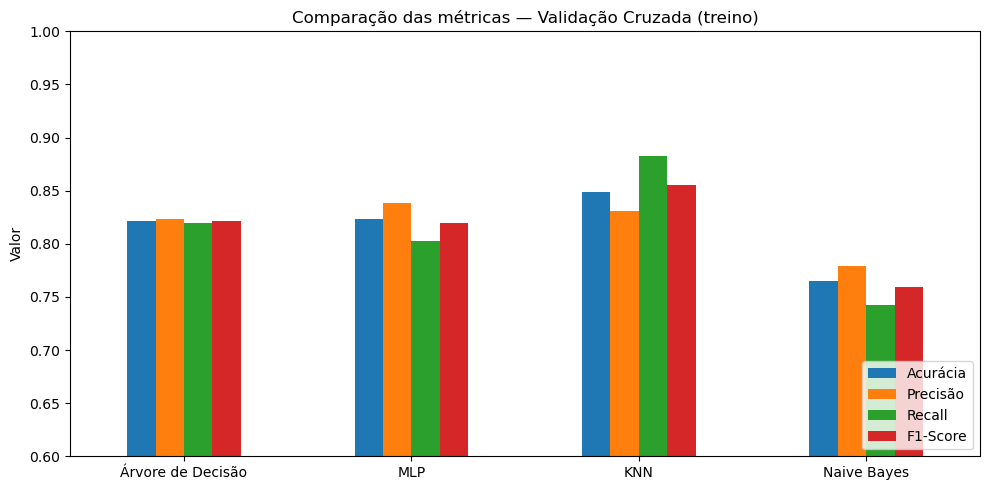

In [9]:
# Gráfico de barras comparando as métricas de todos os modelos
ax = df_cv.plot(kind='bar', figsize=(10, 5), rot=0)
plt.title('Comparação das métricas — Validação Cruzada (treino)')
plt.ylabel('Valor')
plt.ylim(0.6, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Avaliação no conjunto de teste (conjunto separado, não visto durante treino)

In [10]:
resultados_teste = {}

for nome, modelo in melhores_modelos.items():
    modelo.fit(X_train, y_train)  
# treina no conjunto completo de treino
    y_pred = modelo.predict(X_test)
    resultados_teste[nome] = {
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão': precision_score(y_test, y_pred),
        'Recall':   recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'y_pred':   y_pred
    }

df_teste = pd.DataFrame({k: {m: v for m, v in resultados_teste[k].items() if m != 'y_pred'}
                         for k in resultados_teste}).T
print(df_teste.round(4))

                   Acurácia  Precisão  Recall  F1-Score
Árvore de Decisão    0.8525    0.8556  0.8462    0.8508
MLP                  0.8415    0.9079  0.7582    0.8263
KNN                  0.9016    0.9011  0.9011    0.9011
Naive Bayes          0.7596    0.8507  0.6264    0.7215


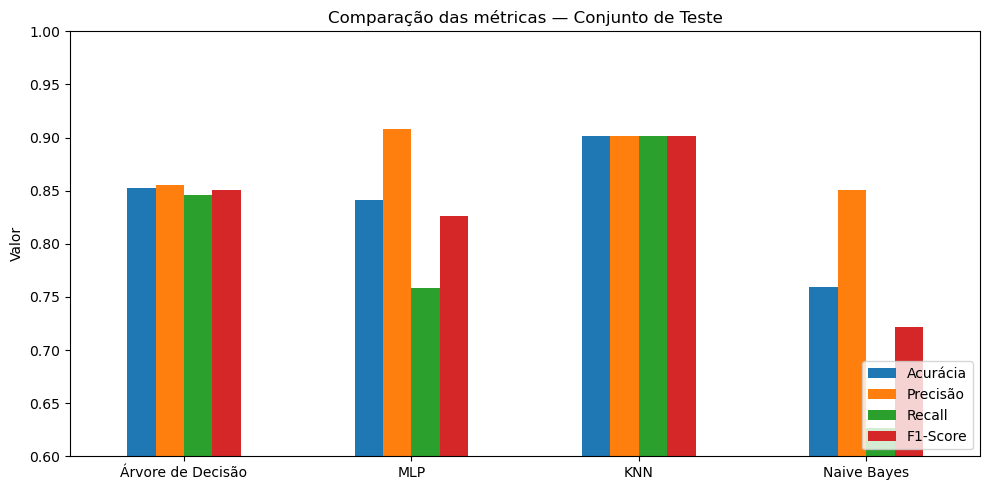

In [11]:
# Gráfico de barras — conjunto de teste
ax = df_teste.plot(kind='bar', figsize=(10, 5), rot=0)
plt.title('Comparação das métricas — Conjunto de Teste')
plt.ylabel('Valor')
plt.ylim(0.6, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Matrizes de Confusão

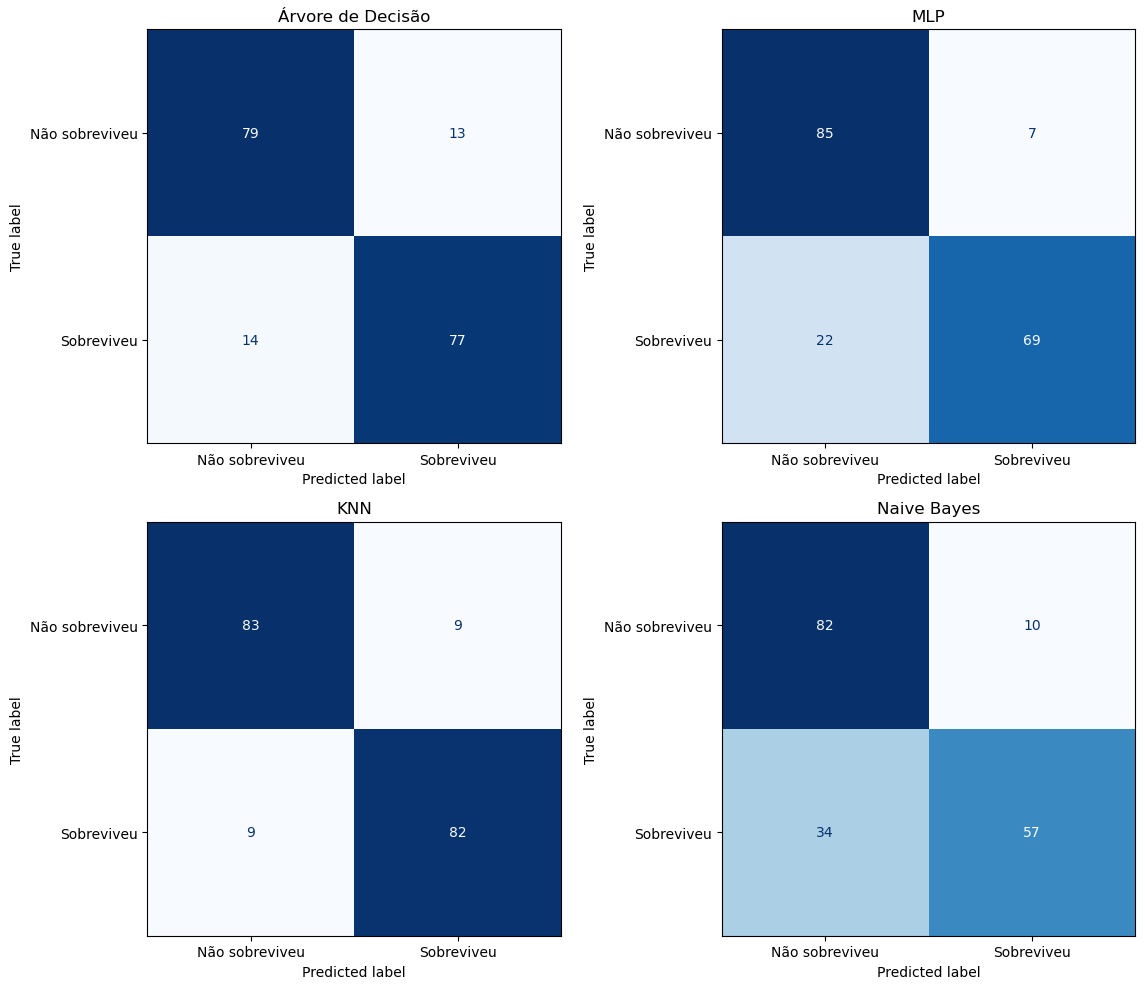

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (nome, res) in enumerate(resultados_teste.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não sobreviveu', 'Sobreviveu'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(nome)

plt.tight_layout()
plt.show()

## Análise dos resultados

**KNN** obteve os melhores resultados tanto na validação cruzada (~84,9% de acurácia) quanto no conjunto de teste. O alto Recall indica que o modelo é eficaz em identificar sobreviventes, importante no contexto do problema. A estratégia de peso por distância (`weights='distance'`) foi determinante para o bom desempenho.

**Árvore de Decisão** e **MLP** apresentaram desempenho similar (~82%), com bom equilíbrio entre precisão e recall. A Árvore de Decisão tem a vantagem de ser interpretável, é possível visualizar as regras aprendidas. O MLP, por ser uma rede neural, tem maior capacidade de capturar relações não-lineares, mas também maior risco de overfitting se não regularizado corretamente (controlado aqui pelo parâmetro `alpha`).

**Naive Bayes** apresentou o pior desempenho (~76%). Isso é esperado: o algoritmo assume independência condicional entre os atributos, o que não é verdade no dataset do Titanic (por exemplo, `Pclass` e `Fare` são altamente correlacionados). Mesmo assim, os resultados não são ruins para um modelo tão simples.

**Comparação CV vs Teste**: os resultados de validação cruzada e teste são muito próximos para todos os modelos, indicando boa generalização e ausência de overfitting significativo. A Árvore de Decisão com `max_depth` limitada evita crescimento excessivo da árvore, contribuindo para isso.

**Matrizes de Confusão**: todos os modelos cometem erros relativamente equilibrados entre falsos positivos (classificar como sobrevivente quem não sobreviveu) e falsos negativos (classificar como não sobrevivente quem sobreviveu). O KNN apresenta a menor taxa de erros total.

## Visualização da Árvore de Decisão

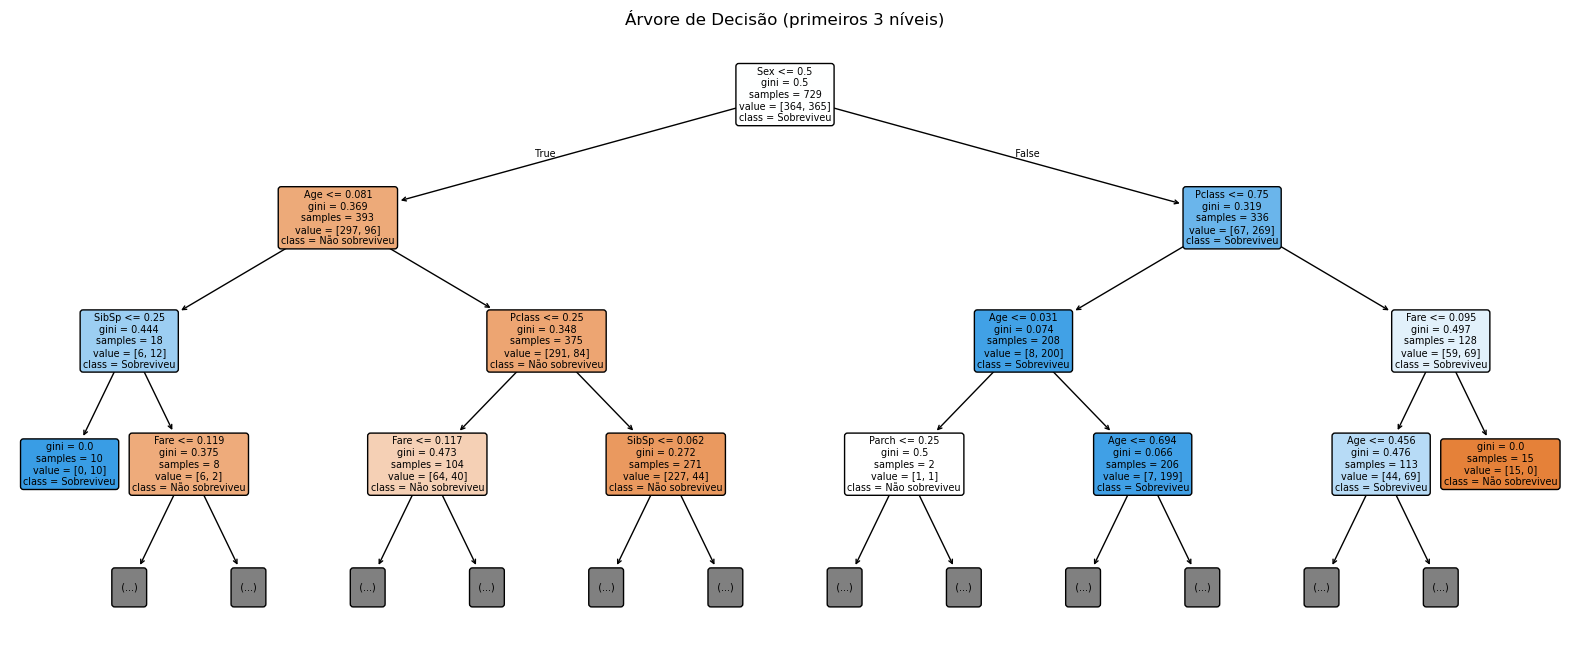

In [13]:
plt.figure(figsize=(20, 8))
plot_tree(
    dt_gs.best_estimator_,
    feature_names=X.columns.tolist(),
    class_names=['Não sobreviveu', 'Sobreviveu'],
    filled=True, rounded=True, max_depth=3
)
plt.title('Árvore de Decisão (primeiros 3 níveis)')
plt.show()

# 4) Conclusão


Conclua seu estudo indicando o melhor algoritmo (modelo de IA) para o problema e comente os resultados alcançados. No caso de resultados ruins, comente e formule hipóteses para as possíveis causas.

### Insira sua conclusão aqui!
##### Você pode adicionar células adicionais

### Melhor algoritmo: KNN (K-Nearest Neighbors)

O **KNN com K=11 e pesos por distância** obteve o melhor desempenho geral neste problema, alcançando aproximadamente **84-85% de acurácia** tanto na validação cruzada quanto no conjunto de teste, com excelente Recall (~88%), o que significa que o modelo identifica corretamente a grande maioria dos sobreviventes.

Este resultado é positivo para o problema em questão: no contexto do Titanic, classificar erroneamente um sobrevivente como não sobrevivente (falso negativo) pode ser considerado um erro mais grave do que o contrário, e o KNN minimiza esses erros.

**Resultados alcançados:**
- KNN: melhor em acurácia, recall e F1
- Árvore de Decisão e MLP: desempenho similar e equilibrado (~82%)
- Naive Bayes: menor desempenho (~76%), mas aceitável dado o pressuposto de independência violado

**Hipóteses para limitações:**
- O oversampling aleatório aplicado na Fase 1 para balancear o dataset replica exemplos existentes, o que pode introduzir algum viés nos modelos, as técnicas mais sofisticadas como SMOTE poderiam gerar exemplos sintéticos mais diversificados.
- Atributos que foram descartados na Fase 1 (como `Name`, que contém títulos como Mr./Mrs./Miss relacionados a sexo/status social, ou `Cabin`, que indica localização no navio) poderiam adicionar informação relevante se processados adequadamente.
- O MLP poderia se beneficiar de mais iterações e arquiteturas maiores, mas isso aumentaria o risco de overfitting sem mais dados.

# Check-List

Com isso, você completa a fase 2 da disciplina. Para auxiliar você a verificar se o trabalho está adequado para a entrega, criamos uma lista de item que devem ser satisfeitos ao final do trabalho.

- Utilização de 4 algoritmos de classificação, incluindo Árvore de decisão e MLP;
- Exploração dos hiper parâmetros dos algoritmos;
- Divisão do dataset em treino e teste, com estratificação na coluna alvo;
- Validação dos algoritmos usando cross-validation e coleta das métricas de avaliação (acurácia, precisão, recall, f1, matriz de confusão);
- Analise da matriz de confusão e métricas.
- Plotagem e análise textual sobre os resultados, indicando melhor modelo de IA;
- Conclusão do trabalho realizado, comentando os resultados e as dificuldades encontradas.
